# Credit Card Fraud Detection - Complete ML Pipeline

## Dataset

Dataset from Kaggle:

[https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

CSV File:

```text
creditcard.csv
```

---

# Why This Dataset Is Important

This dataset covers several advanced ML concepts not fully covered earlier.

| Concept                        | Covered |
| ------------------------------ | ------- |
| Imbalanced Data                | ✅       |
| SMOTE                          | ✅       |
| PCA Features                   | ✅       |
| Anomaly Detection Thinking     | ✅       |
| Precision vs Recall Importance | ✅       |
| ROC-AUC                        | ✅       |
| PR Curve                       | ✅       |
| Cross Validation               | ✅       |
| Random Forest                  | ✅       |
| Hyperparameter Tuning          | ✅       |

---

# Business Problem

Detect whether a transaction is:

* Fraudulent
* Genuine

Target Column:

```text
Class
```

| Value | Meaning |
| ----- | ------- |
| 0     | Genuine |
| 1     | Fraud   |

---

# Important Real-World Concept

Fraud datasets are highly imbalanced.

Example:

| Class   | Count  |
| ------- | ------ |
| Genuine | 284315 |
| Fraud   | 492    |

This creates real ML challenges.

---


# 1. IMPORT LIBRARIES

In [1]:
# =========================================================
# 1. IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve
)

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')


# 2. DATA GATHERING

In [3]:
# =========================================================
# 2. DATA GATHERING
# =========================================================

# Read dataset

df = pd.read_csv("data/CreditCardFraudDetection/creditcard.csv")

print("=" * 50)
print("FIRST 5 ROWS")
print("=" * 50)

print(df.head())


FIRST 5 ROWS
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

# 3. BASIC DATA UNDERSTANDING

In [4]:
# =========================================================
# 3. BASIC DATA UNDERSTANDING
# =========================================================

print("\nDATASET SHAPE")
print(df.shape)

print("\nCOLUMN NAMES")
print(df.columns)

print("\nDATA TYPES")
print(df.dtypes)

print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nTARGET DISTRIBUTION")
print(df['Class'].value_counts())



DATASET SHAPE
(284807, 31)

COLUMN NAMES
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

DATA TYPES
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

MISSING VALUES
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0


# 4. CLASS IMBALANCE VISUALIZATION

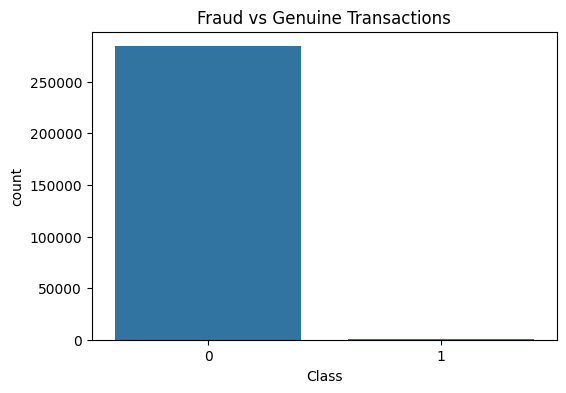

In [5]:
# =========================================================
# 4. CLASS IMBALANCE VISUALIZATION
# =========================================================

plt.figure(figsize=(6,4))

sns.countplot(
    x='Class',
    data=df
)

plt.title("Fraud vs Genuine Transactions")

plt.show()


# 5. FRAUD PERCENTAGE

In [7]:
# =========================================================
# 5. FRAUD PERCENTAGE
# =========================================================

fraud_percentage = (
    df['Class'].value_counts(normalize=True) * 100
)

print("\nCLASS PERCENTAGE")
print(fraud_percentage)



CLASS PERCENTAGE
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


# EDA - UNIVARIATE ANALYSIS

In [8]:
# =========================================================
# =========================================================
# EDA - UNIVARIATE ANALYSIS
# =========================================================
# =========================================================


# 6. AMOUNT DISTRIBUTION

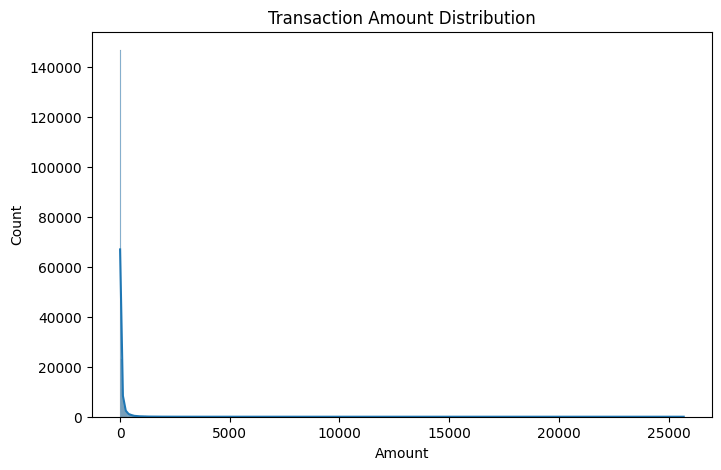

In [9]:
# =========================================================
# 6. AMOUNT DISTRIBUTION
# =========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df['Amount'],
    kde=True
)

plt.title("Transaction Amount Distribution")

plt.show()


# 7. TIME DISTRIBUTION

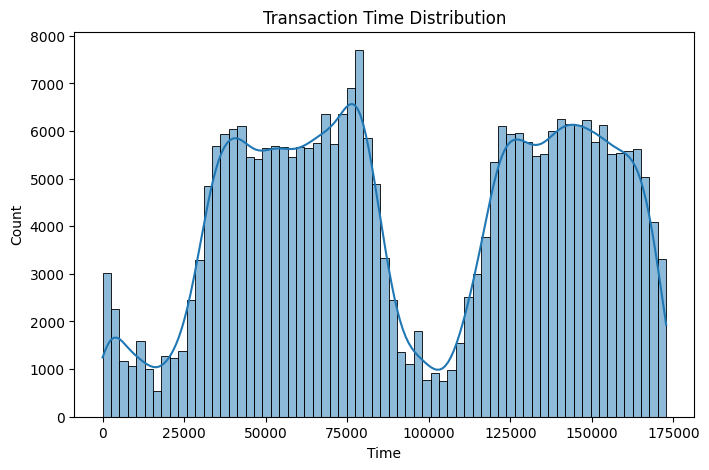

In [10]:
# =========================================================
# 7. TIME DISTRIBUTION
# =========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df['Time'],
    kde=True
)

plt.title("Transaction Time Distribution")

plt.show()


# 8. BOXPLOT - OUTLIERS

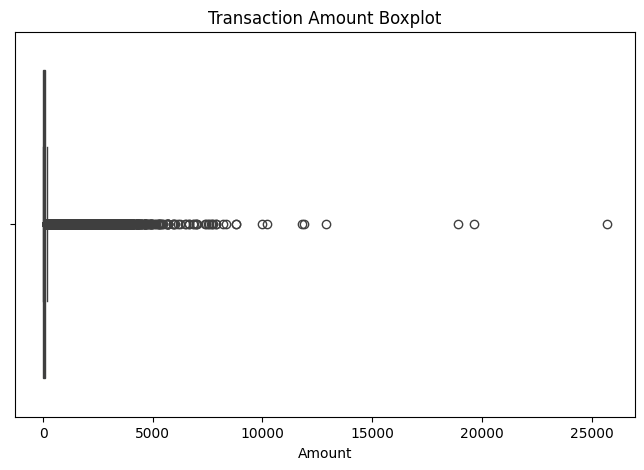

In [11]:
# =========================================================
# 8. BOXPLOT - OUTLIERS
# =========================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['Amount']
)

plt.title("Transaction Amount Boxplot")

plt.show()


# MULTIVARIATE ANALYSIS

In [12]:
# =========================================================
# =========================================================
# MULTIVARIATE ANALYSIS
# =========================================================
# =========================================================


# 9. HEATMAP

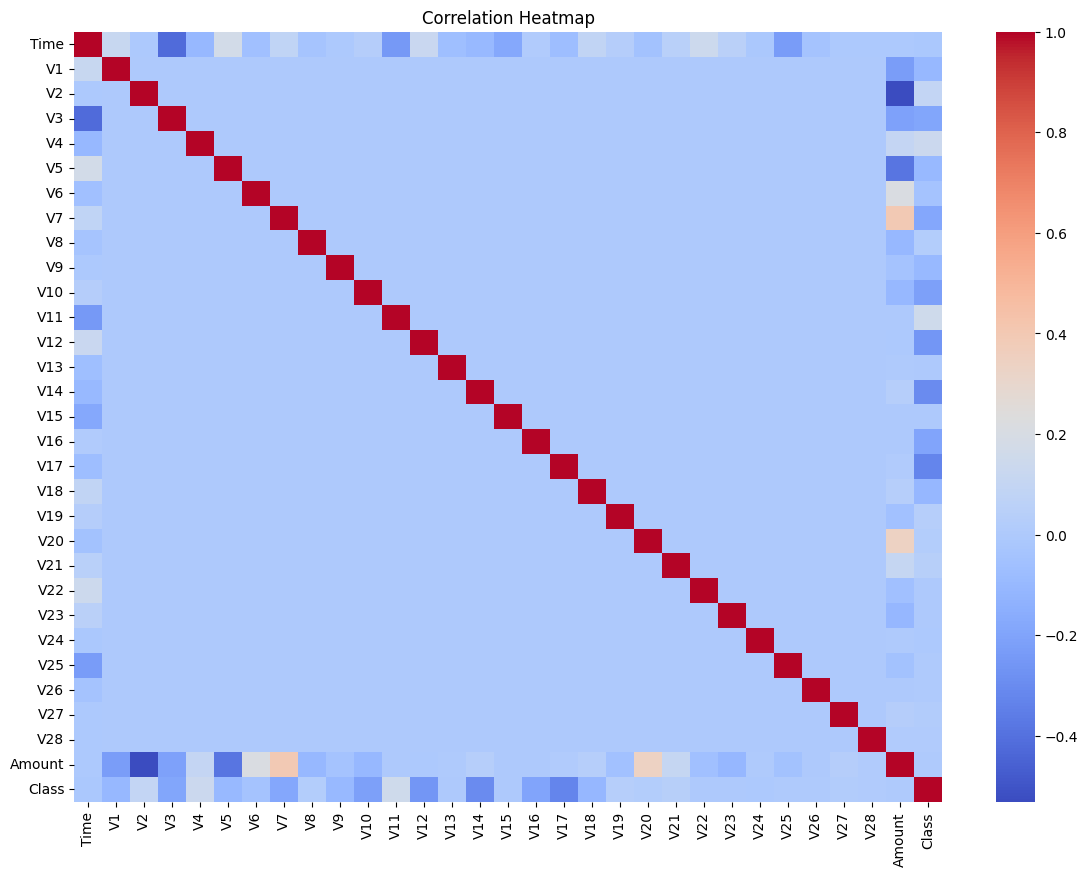

In [13]:
# =========================================================
# 9. HEATMAP
# =========================================================

plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()


# 10. FRAUD VS AMOUNT

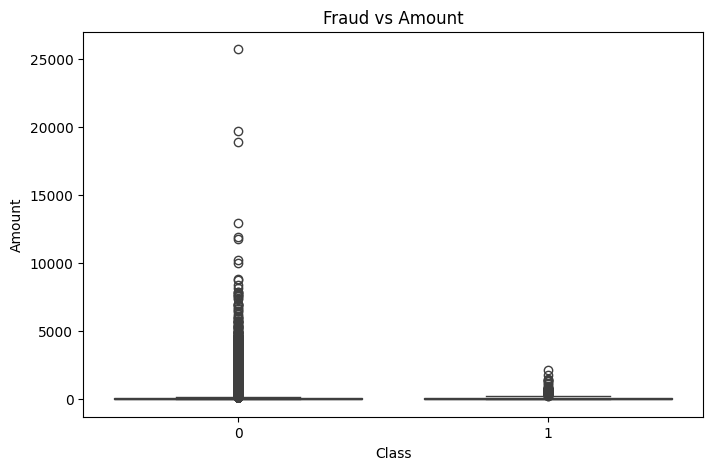

In [15]:
# =========================================================
# 10. FRAUD VS AMOUNT
# =========================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Class',
    y='Amount',
    data=df
)

plt.title("Fraud vs Amount")

plt.show()


# 11. SCATTER PLOT

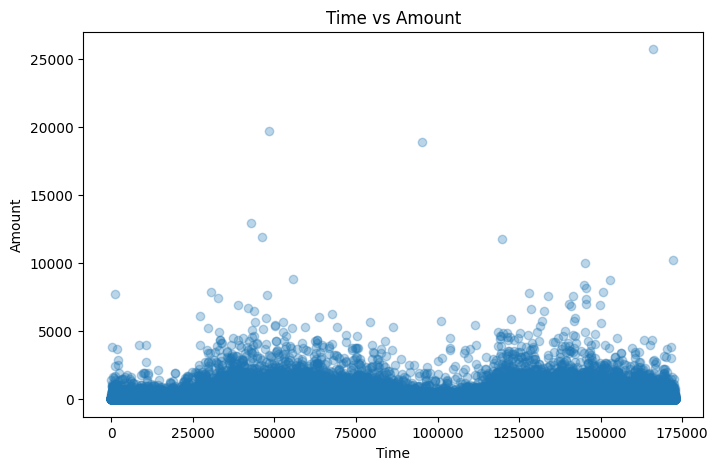

In [16]:
# =========================================================
# 11. SCATTER PLOT
# =========================================================

plt.figure(figsize=(8,5))

plt.scatter(
    df['Time'],
    df['Amount'],
    alpha=0.3
)

plt.xlabel("Time")

plt.ylabel("Amount")

plt.title("Time vs Amount")

plt.show()


# FEATURE ENGINEERING

In [17]:
# =========================================================
# =========================================================
# FEATURE ENGINEERING
# =========================================================
# =========================================================


# 12. FEATURE SCALING

In [18]:
# =========================================================
# 12. FEATURE SCALING
# =========================================================

scaler = StandardScaler()

# Scale Amount and Time

df['Amount_Scaled'] = scaler.fit_transform(
    df[['Amount']]
)

df['Time_Scaled'] = scaler.fit_transform(
    df[['Time']]
)


# 13. DROP ORIGINAL COLUMNS

In [19]:
# =========================================================
# 13. DROP ORIGINAL COLUMNS
# =========================================================

# Keep scaled versions only

df.drop(
    columns=['Amount', 'Time'],
    inplace=True
)


# 14. FEATURE SELECTION

In [20]:
# =========================================================
# 14. FEATURE SELECTION
# =========================================================

X = df.drop('Class', axis=1)

y = df['Class']


# 15. TRAIN TEST SPLIT

In [21]:
# =========================================================
# 15. TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTRAIN SHAPE")
print(X_train.shape)

print("\nTEST SHAPE")
print(X_test.shape)



TRAIN SHAPE
(227845, 30)

TEST SHAPE
(56962, 30)


# 16. SMOTE - HANDLE IMBALANCED DATA

In [22]:
# =========================================================
# 16. SMOTE - HANDLE IMBALANCED DATA
# =========================================================

# SMOTE creates synthetic fraud samples

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("\nAFTER SMOTE")
print(pd.Series(y_train_smote).value_counts())



AFTER SMOTE
Class
0    227451
1    227451
Name: count, dtype: int64


# MODEL BUILDING

In [23]:
# =========================================================
# =========================================================
# MODEL BUILDING
# =========================================================
# =========================================================


# 17. LOGISTIC REGRESSION

In [24]:
# =========================================================
# 17. LOGISTIC REGRESSION
# =========================================================

log_model = LogisticRegression()

log_model.fit(
    X_train_smote,
    y_train_smote
)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

# 18. RANDOM FOREST

In [25]:
# =========================================================
# 18. RANDOM FOREST
# =========================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train_smote,
    y_train_smote
)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

# 19. PREDICTIONS

In [26]:
# =========================================================
# 19. PREDICTIONS
# =========================================================

log_pred = log_model.predict(X_test)

rf_pred = rf_model.predict(X_test)


# 20. PROBABILITY PREDICTIONS

In [27]:
# =========================================================
# 20. PROBABILITY PREDICTIONS
# =========================================================

rf_prob = rf_model.predict_proba(X_test)[:,1]


# MODEL EVALUATION

In [28]:
# =========================================================
# =========================================================
# MODEL EVALUATION
# =========================================================
# =========================================================


# 21. ACCURACY

In [29]:
# =========================================================
# 21. ACCURACY
# =========================================================

print("\nLOGISTIC REGRESSION ACCURACY")
print(accuracy_score(y_test, log_pred))

print("\nRANDOM FOREST ACCURACY")
print(accuracy_score(y_test, rf_pred))



LOGISTIC REGRESSION ACCURACY
0.9742635441171307

RANDOM FOREST ACCURACY
0.999385555282469


# 22. CONFUSION MATRIX

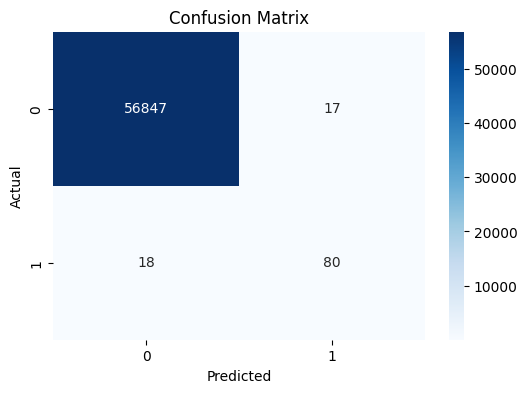

In [30]:
# =========================================================
# 22. CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()


# 23. CLASSIFICATION REPORT

In [31]:
# =========================================================
# 23. CLASSIFICATION REPORT
# =========================================================

print("\nCLASSIFICATION REPORT")

print(
    classification_report(
        y_test,
        rf_pred
    )
)



CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.82      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



# 24. ROC CURVE

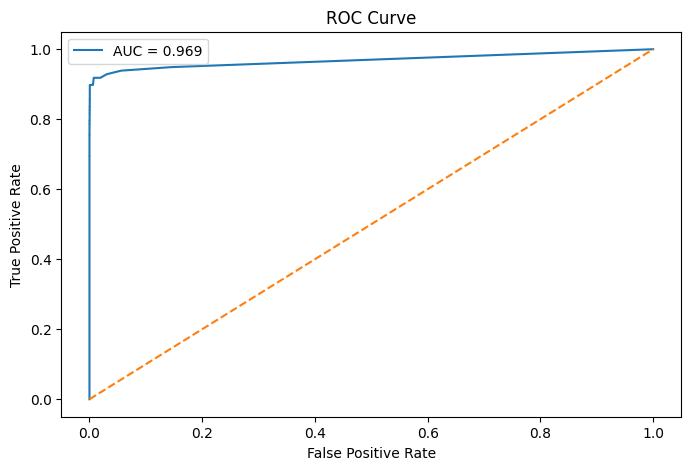

In [32]:
# =========================================================
# 24. ROC CURVE
# =========================================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    rf_prob
)

auc_score = roc_auc_score(
    y_test,
    rf_prob
)

plt.figure(figsize=(8,5))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {auc_score:.3f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# 25. PRECISION-RECALL CURVE

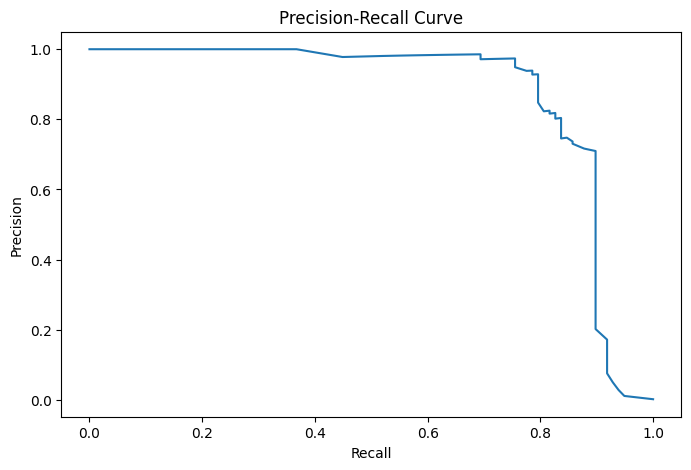

In [33]:
# =========================================================
# 25. PRECISION-RECALL CURVE
# =========================================================

precision, recall, thresholds = precision_recall_curve(
    y_test,
    rf_prob
)

plt.figure(figsize=(8,5))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.show()


# 26. CROSS VALIDATION

In [34]:
# =========================================================
# 26. CROSS VALIDATION
# =========================================================

cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring='roc_auc'
)

print("\nCROSS VALIDATION AUC SCORES")
print(cv_scores)

print("\nMEAN CV SCORE")
print(cv_scores.mean())



CROSS VALIDATION AUC SCORES
[0.72954427 0.90670399 0.91336445 0.95949152 0.94678581]

MEAN CV SCORE
0.8911780091265371


# 27. FEATURE IMPORTANCE

In [35]:
# =========================================================
# 27. FEATURE IMPORTANCE
# =========================================================

importance_df = pd.DataFrame({

    'Feature': X.columns,

    'Importance': rf_model.feature_importances_

})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\nTOP IMPORTANT FEATURES")
print(importance_df.head(10))



TOP IMPORTANT FEATURES
   Feature  Importance
13     V14    0.221890
9      V10    0.109153
3       V4    0.107627
16     V17    0.082802
11     V12    0.081718
10     V11    0.072230
2       V3    0.070561
15     V16    0.034439
6       V7    0.025885
1       V2    0.024716


# 28. FEATURE IMPORTANCE GRAPH

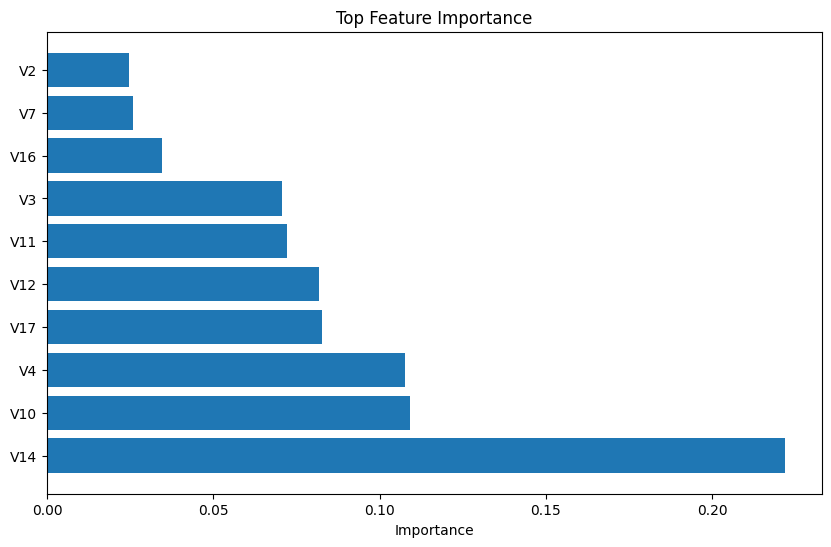

In [36]:
# =========================================================
# 28. FEATURE IMPORTANCE GRAPH
# =========================================================

plt.figure(figsize=(10,6))

plt.barh(
    importance_df['Feature'].head(10),
    importance_df['Importance'].head(10)
)

plt.title("Top Feature Importance")

plt.xlabel("Importance")

plt.show()


# 29. HYPERPARAMETER TUNING

In [37]:
# =========================================================
# 29. HYPERPARAMETER TUNING
# =========================================================

param_grid = {

    'n_estimators': [50, 100],

    'max_depth': [5, 10]

}


grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='roc_auc'
)


grid_search.fit(
    X_train_smote,
    y_train_smote
)

print("\nBEST PARAMETERS")
print(grid_search.best_params_)



BEST PARAMETERS
{'max_depth': 10, 'n_estimators': 100}


# 30. SAMPLE PREDICTION

In [38]:
# =========================================================
# 30. SAMPLE PREDICTION
# =========================================================

sample_transaction = X_test.iloc[[0]]

sample_prediction = rf_model.predict(
    sample_transaction
)

sample_probability = rf_model.predict_proba(
    sample_transaction
)[:,1]

print("\nSAMPLE PREDICTION")

if sample_prediction[0] == 1:

    print("Fraud Transaction")

else:

    print("Genuine Transaction")

print("\nFRAUD PROBABILITY")
print(sample_probability[0])



SAMPLE PREDICTION
Genuine Transaction

FRAUD PROBABILITY
0.0


# ==================================
# IMPORTANT CONCEPTS COVERED
# ==================================

"""
IMPORTANT NEW CONCEPTS:

1. Imbalanced Data
2. SMOTE
3. Random Forest
4. Cross Validation
5. ROC Curve
6. Precision-Recall Curve
7. Hyperparameter Tuning
8. Feature Importance
9. Fraud Detection
10. AUC Score

IMPORTANT REAL-WORLD CONCEPTS:

SMOTE:
Synthetic Minority Oversampling Technique

Cross Validation:
More reliable model evaluation

Random Forest:
Ensemble learning algorithm

ROC-AUC:
Classification quality measurement

Precision-Recall:
Very important for imbalanced datasets

Hyperparameter Tuning:
Finding best model configuration
"""
```

---

# Important New Concepts Learned

| Concept                | Importance             |
| ---------------------- | ---------------------- |
| SMOTE                  | handle imbalance       |
| Random Forest          | ensemble ML            |
| Cross Validation       | robust evaluation      |
| GridSearchCV           | hyperparameter tuning  |
| Precision-Recall Curve | imbalance analysis     |
| AUC                    | classification quality |
| Feature Importance     | interpretability       |

---
